In [1]:
import matplotlib.pyplot as plt
from statsmodels.base.model import GenericLikelihoodModel
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia
from boulder_statistics.analysis.fit_params.weibull_fit_params import WeibullFitParams

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable


from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [2]:
from boulder_statistics.analysis.quick_calculate_Weibull import WeibullFittingFunction
from boulder_statistics.analysis.sensitivity_model import SensitivityModel

fit = WeibullFittingFunction(dp, LAD_min=0, sensitivity_model = SensitivityModel(dp.db_jaccard_agg))

In [3]:
# from statsmodels.base.model import GenericLikelihoodModelResults


# mle_model: GenericLikelihoodModelResults = fit.MLE_fit(
#     optimize_params = WeibullFitParams(lambda_ = 0.0002, k = 0.2053),
#     verbose = False,
#     summary=True
# )

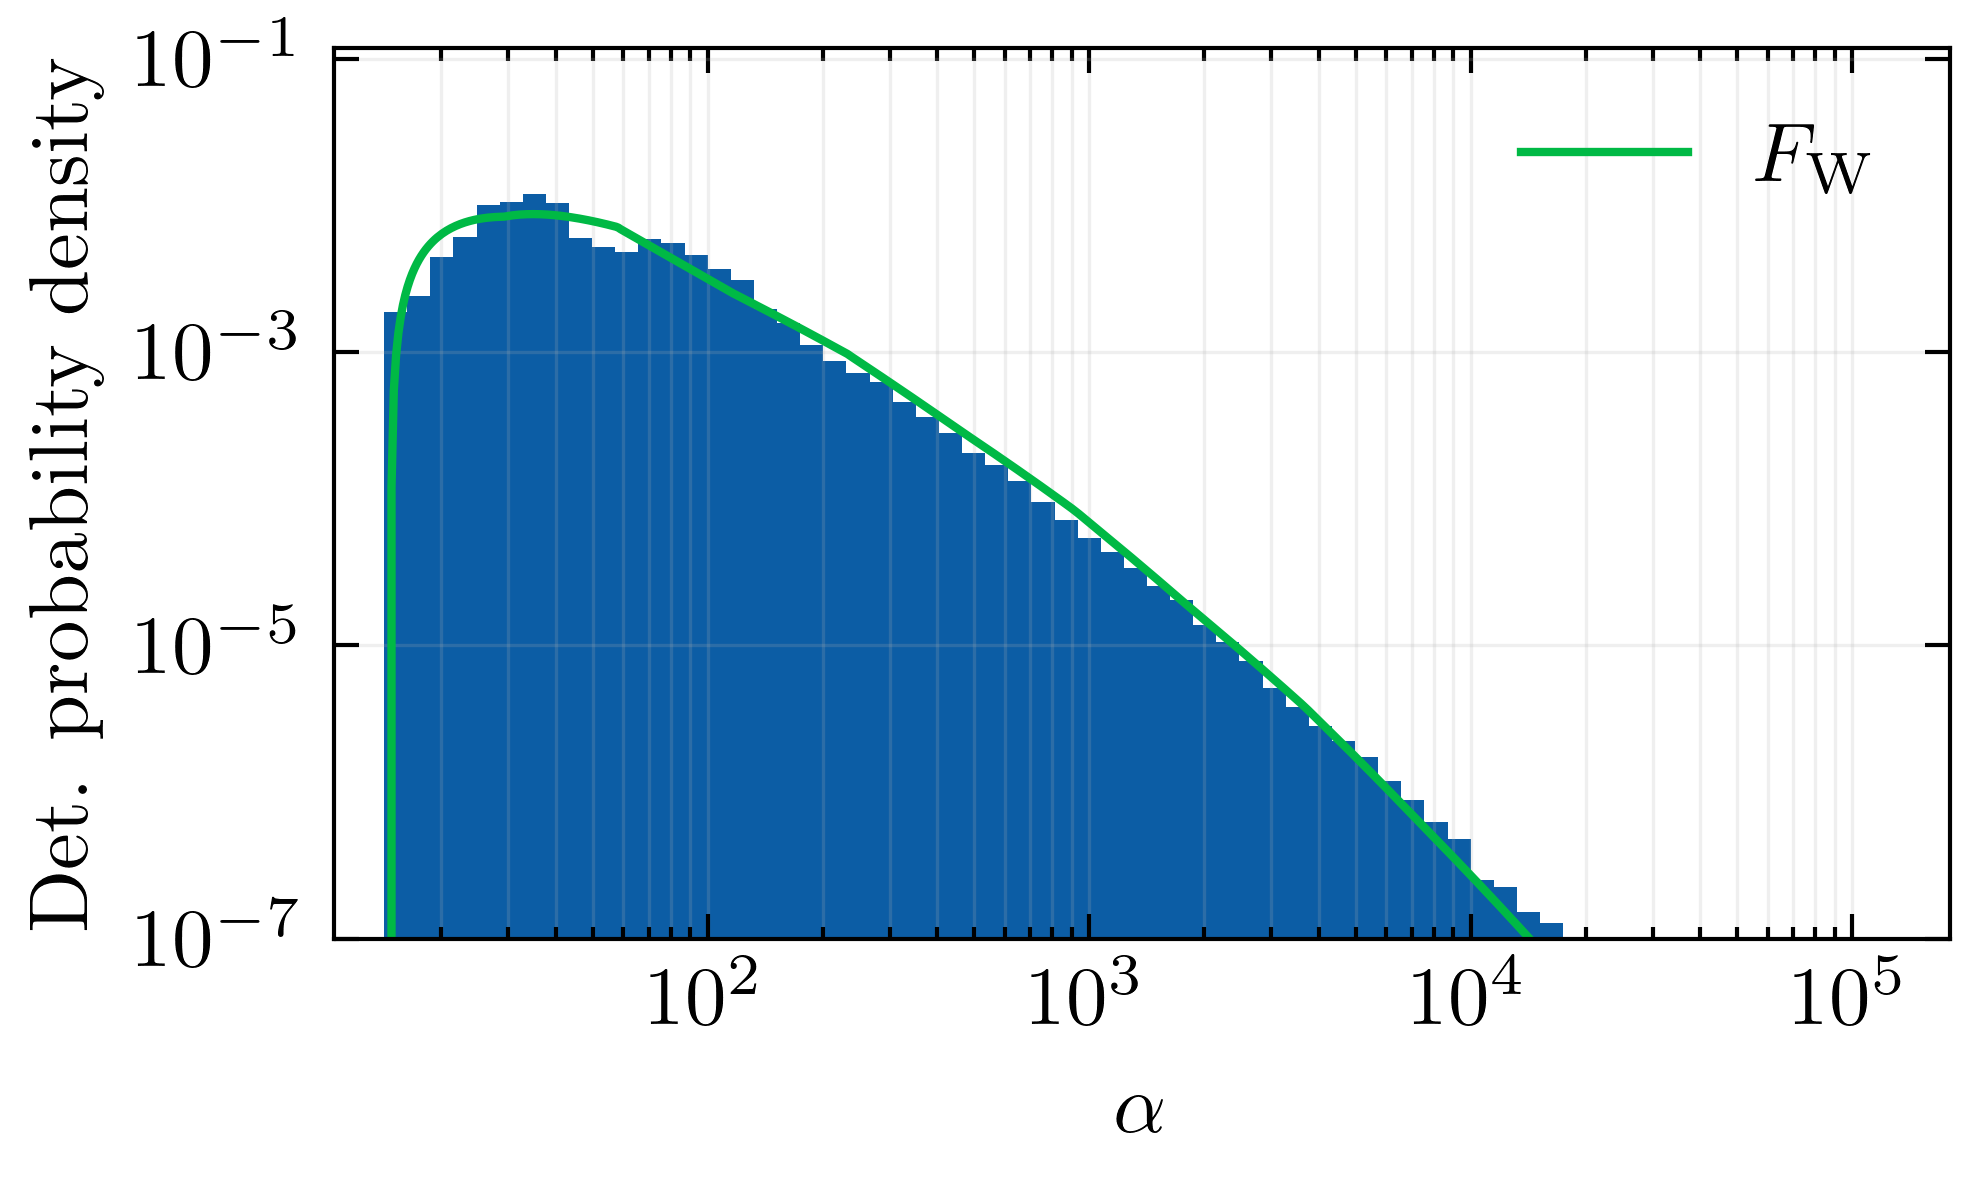

In [7]:
# 1.6290 0.6006 for LAD min = 2

alphas_hist = np.geomspace(1, 1e6, 100)
alphas = np.geomspace(1, 1e6, 1000)

counts, bins, _ = plt.hist(fit.cleaned_data.collect()["alpha"].to_numpy(),
                           alphas_hist, density = True)

# fit_params = WeibullFitParams(*mle_model.params)
fit_params = WeibullFitParams(lambda_ = 0.0002, k = 0.2053)
plt.plot(alphas, fit.F_norm(alphas, fit_params, s_model=SensitivityModel(dp.db_jaccard_agg).best_p_function), label = r"$F_{\text{W}}$")

plt.ylim(1e-7, counts.max() * 10)
plt.xlim(fit.plot_range[0] * 0.7, fit.plot_range[1] * 0.5)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
plt.savefig("overall_fit.png")
plt.show()

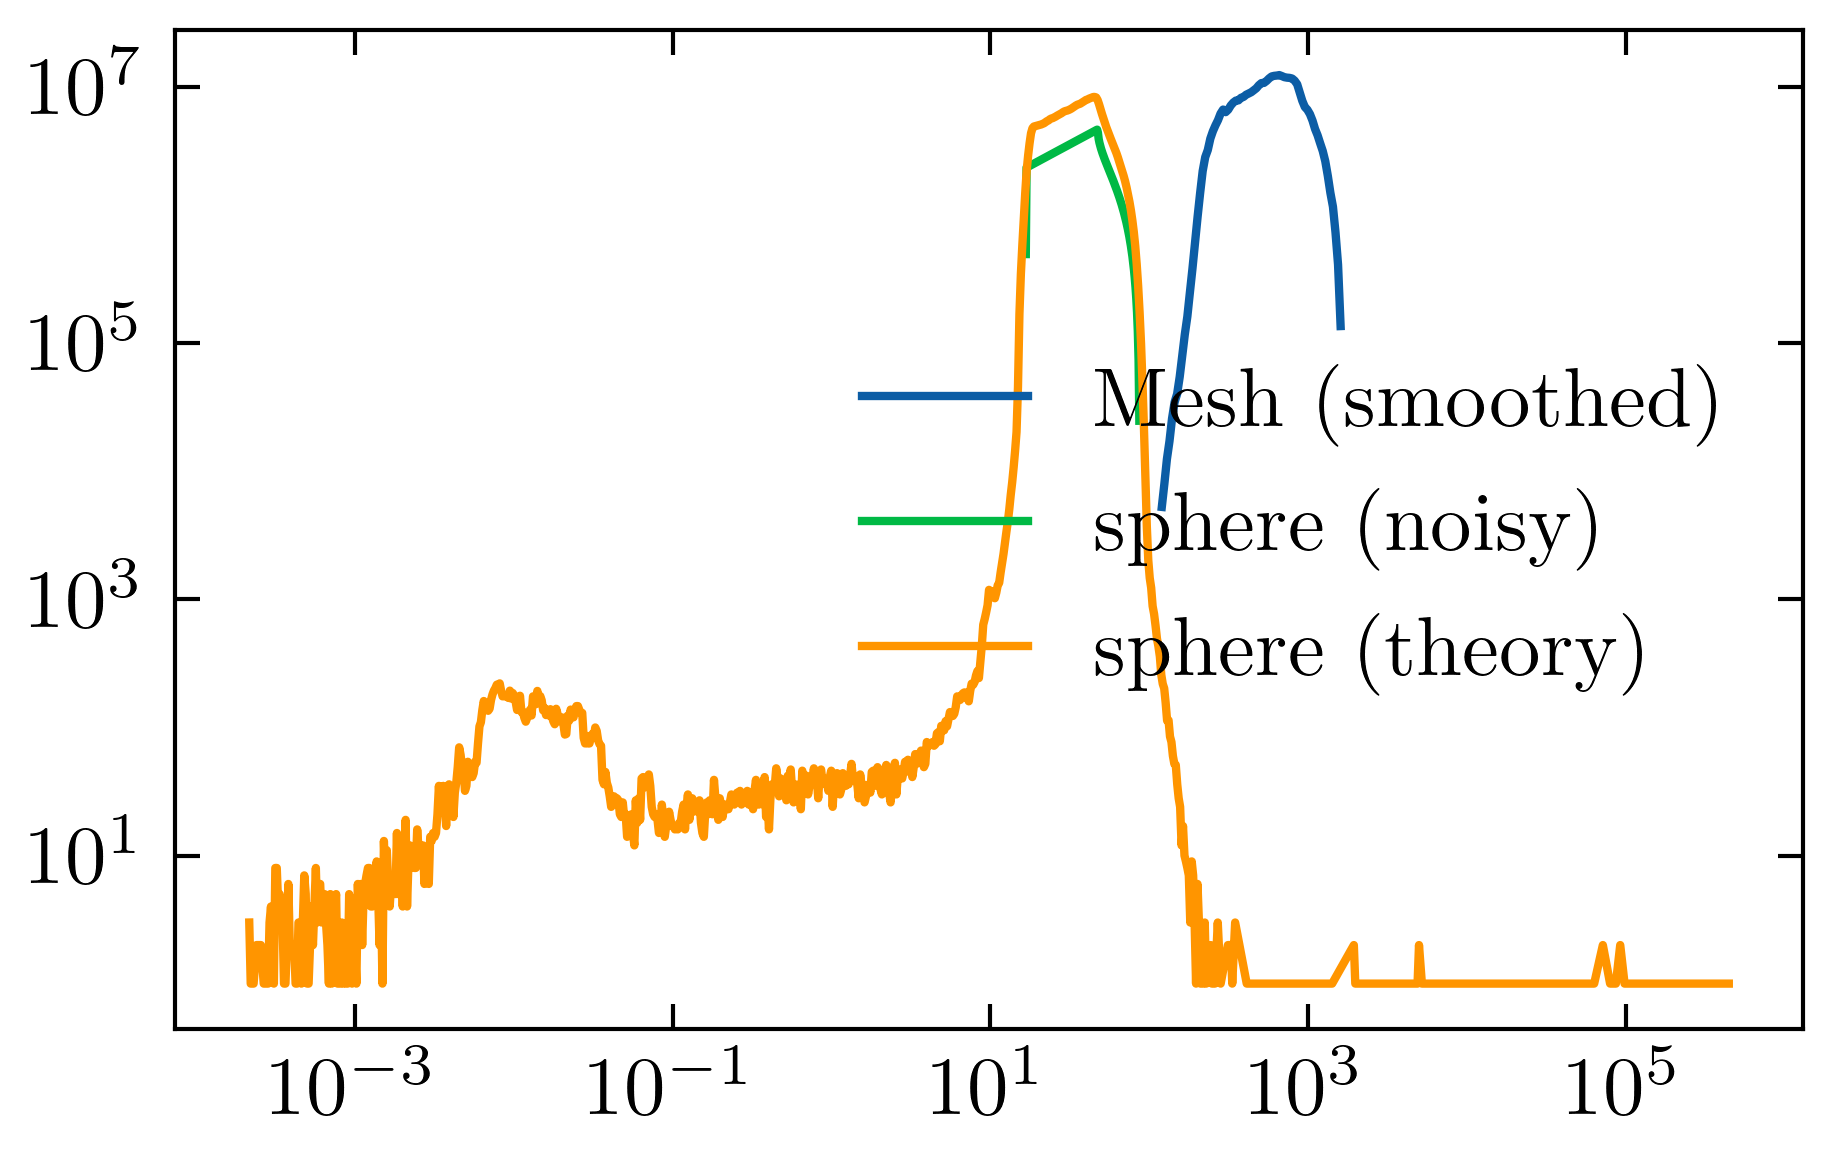

In [5]:
bin_centers = 0.5 * (dp.Phi_counts_smoothed_bins[:-1] + dp.Phi_counts_smoothed_bins[1:])
bin_widths = np.abs(dp.Phi_counts_smoothed_bins[:-1] - dp.Phi_counts_smoothed_bins[1:])
mask = (dp.Phi_counts_smoothed_counts / bin_widths > 10**3) & (dp.Phi_counts_smoothed_counts * bin_widths > 10**3)
plt.plot(bin_centers[mask], dp.Phi_counts_smoothed_counts[mask], label = "Mesh (smoothed)")

bin_centers = 0.5 * (dp.Phi_counts_sphere_noisy_bins[:-1] + dp.Phi_counts_sphere_noisy_bins[1:])
mask = dp.Phi_counts_sphere_noisy_counts != 0
plt.plot(bin_centers[mask], dp.Phi_counts_sphere_noisy_counts[mask], label = "sphere (noisy)")

bin_centers = 0.5 * (dp.Phi_counts_sphere_theory_bins[:-1] + dp.Phi_counts_sphere_theory_bins[1:])
mask = dp.Phi_counts_sphere_theory_counts != 0
plt.plot(bin_centers[mask], dp.Phi_counts_sphere_theory_counts[mask], label = "sphere (theory)")

plt.xscale("log")
plt.yscale("log")
plt.legend()